In [ ]:
import sys
import tensDorflow as tf

print("Python:", sys.version)
print("Executable:", sys.executable)
print("TensorFlow:", tf.__version__)

Python: 3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]
Executable: c:\Users\bipla\breastcancer_env\Scripts\python.exe
TensorFlow: 2.21.0


In [3]:
import sys
import platform

print("Python:", sys.version)
print("Executable:", sys.executable)
print("Platform:", sys.platform)
print("Machine:", platform.machine())

Python: 3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]
Executable: c:\Users\bipla\breastcancer_env\Scripts\python.exe
Platform: win32
Machine: AMD64


In [4]:
try:
    import tensorflow as tf
    print("TensorFlow:", tf.__version__)
except Exception as e:
    print("TensorFlow error:", e)

TensorFlow: 2.21.0


In [5]:
%pip install kagglehub
import kagglehub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\bipla\breastcancer_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
path = kagglehub.dataset_download("ambarish/breakhis")
print("Dataset path:")

print(path)

100%|██████████| 3.99G/3.99G [08:03<00:00, 8.85MB/s] 

Extracting files...


Dataset path:
C:\Users\bipla\.cache\kagglehub\datasets\ambarish\breakhis\versions\4


In [7]:
from pathlib import Path

dataset_path = Path(r"C:\Users\bipla\.cache\kagglehub\datasets\ambarish\breakhis\versions\4")

print("Dataset exists:", dataset_path.exists())
print("\nContents:")

for item in dataset_path.iterdir():
    print(item.name, "->", "Folder" if item.is_dir() else "File")

Dataset exists: True

Contents:
BreaKHis_v1 -> Folder
Folds.csv -> File


In [8]:
image_extensions = {".png", ".jpg", ".jpeg", ".tif", ".tiff"}

image_files = [
    p for p in dataset_path.rglob("*")
    if p.is_file() and p.suffix.lower() in image_extensions
]

print("Total image files:", len(image_files))

print("\nFirst 10 images:")
for p in image_files[:10]:
    print(p)

Total image files: 7909

First 10 images:
C:\Users\bipla\.cache\kagglehub\datasets\ambarish\breakhis\versions\4\BreaKHis_v1\BreaKHis_v1\histology_slides\breast\malignant\SOB\papillary_carcinoma\SOB_M_PC_15-190EF\100X\SOB_M_PC-15-190EF-100-001.png
C:\Users\bipla\.cache\kagglehub\datasets\ambarish\breakhis\versions\4\BreaKHis_v1\BreaKHis_v1\histology_slides\breast\malignant\SOB\papillary_carcinoma\SOB_M_PC_15-190EF\100X\SOB_M_PC-15-190EF-100-002.png
C:\Users\bipla\.cache\kagglehub\datasets\ambarish\breakhis\versions\4\BreaKHis_v1\BreaKHis_v1\histology_slides\breast\malignant\SOB\papillary_carcinoma\SOB_M_PC_15-190EF\100X\SOB_M_PC-15-190EF-100-003.png
C:\Users\bipla\.cache\kagglehub\datasets\ambarish\breakhis\versions\4\BreaKHis_v1\BreaKHis_v1\histology_slides\breast\malignant\SOB\papillary_carcinoma\SOB_M_PC_15-190EF\100X\SOB_M_PC-15-190EF-100-004.png
C:\Users\bipla\.cache\kagglehub\datasets\ambarish\breakhis\versions\4\BreaKHis_v1\BreaKHis_v1\histology_slides\breast\malignant\SOB\papill

In [9]:
import os

print(os.listdir(path))

['BreaKHis_v1', 'Folds.csv']


In [10]:
import os

dataset_path = os.path.join(path, "BreaKHis_v1")

for root, dirs, files in os.walk(dataset_path):
    print(root)
    print("Folders:", dirs[:5])
    print("Files:", files[:5])
    print("-"*50)
    break

C:\Users\bipla\.cache\kagglehub\datasets\ambarish\breakhis\versions\4\BreaKHis_v1
Folders: ['BreaKHis_v1']
Files: []
--------------------------------------------------


In [11]:
import os

dataset_path = os.path.join(path, "BreaKHis_v1", "BreaKHis_v1")

print(dataset_path)
print(os.listdir(dataset_path))

C:\Users\bipla\.cache\kagglehub\datasets\ambarish\breakhis\versions\4\BreaKHis_v1\BreaKHis_v1
['histology_slides']


In [12]:
histology_path = os.path.join(
    path,
    "BreaKHis_v1",
    "BreaKHis_v1",
    "histology_slides",
    "breast"
)

print(histology_path)
print(os.listdir(histology_path))

C:\Users\bipla\.cache\kagglehub\datasets\ambarish\breakhis\versions\4\BreaKHis_v1\BreaKHis_v1\histology_slides\breast
['benign', 'count_files.sh', 'malignant', 'README.txt']


In [13]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step


In [14]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [15]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
with open("model_summary.txt", "w") as f:
    model.summary(print_fn=lambda x: f.write(x + "\n"))

In [ ]:
!cat model_summary.txt

Model: "functional"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │

In [17]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [18]:
!pip install visualkeras
!pip install aggdraw

Defaulting to user installation because normal site-packages is not writeable
     -------------------------------------- 44.9/44.9 KB 737.1 kB/s eta 0:00:00


You should consider upgrading via the 'C:\Program Files\Python39\python.exe -m pip install --upgrade pip' command.


Defaulting to user installation because normal site-packages is not writeable


You should consider upgrading via the 'C:\Program Files\Python39\python.exe -m pip install --upgrade pip' command.


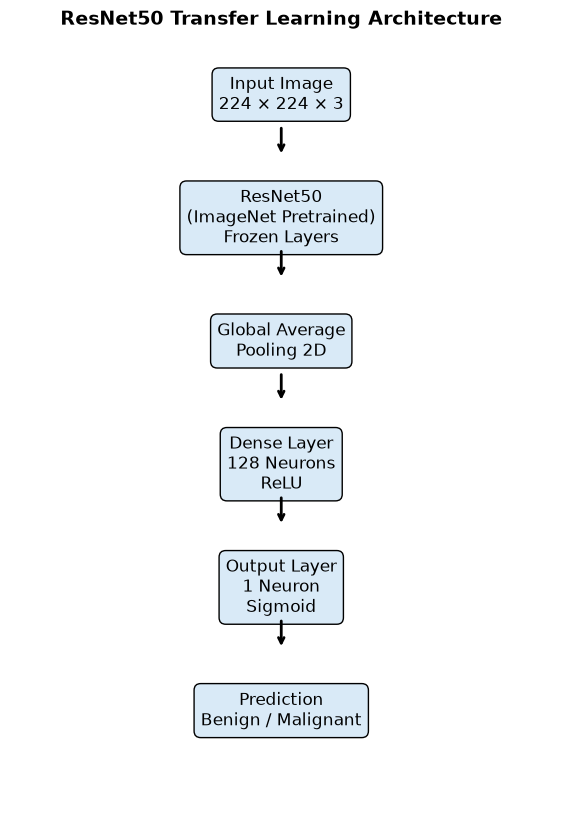

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,10))
ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.axis('off')

layers = [
    "Input Image\n224 × 224 × 3",
    "ResNet50\n(ImageNet Pretrained)\nFrozen Layers",
    "Global Average\nPooling 2D",
    "Dense Layer\n128 Neurons\nReLU",
    "Output Layer\n1 Neuron\nSigmoid",
    "Prediction\nBenign / Malignant"
]

y = 0.92

for i, layer in enumerate(layers):
    ax.text(
        0.5, y, layer,
        ha='center',
        va='center',
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.4",
                  facecolor="#D9EAF7",
                  edgecolor="black")
    )

    if i < len(layers)-1:
        ax.annotate(
            "",
            xy=(0.5, y-0.08),
            xytext=(0.5, y-0.04),
            arrowprops=dict(arrowstyle="->", lw=2)
        )

    y -= 0.16

plt.title("ResNet50 Transfer Learning Architecture", fontsize=14, weight='bold')

plt.savefig("ResNet50_Architecture.png", dpi=300, bbox_inches='tight')
plt.show()

Benign Images : 2480
Malignant Images : 5429


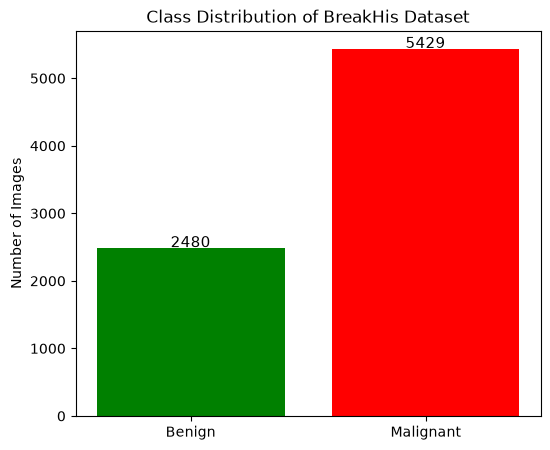

In [20]:
import os
import matplotlib.pyplot as plt

dataset_path = histology_path

benign = 0
malignant = 0

for root, dirs, files in os.walk(os.path.join(dataset_path, "benign")):
    benign += len([f for f in files if f.endswith(".png")])

for root, dirs, files in os.walk(os.path.join(dataset_path, "malignant")):
    malignant += len([f for f in files if f.endswith(".png")])

print("Benign Images :", benign)
print("Malignant Images :", malignant)

plt.figure(figsize=(6,5))
plt.bar(["Benign","Malignant"], [benign, malignant], color=["green","red"])
plt.title("Class Distribution of BreakHis Dataset")
plt.ylabel("Number of Images")

for i,v in enumerate([benign, malignant]):
    plt.text(i,v+20,str(v),ha='center',fontsize=11)

plt.show()

In [22]:
import os
import pandas as pd

image_paths = []
labels = []

for label in ["benign", "malignant"]:
    folder = os.path.join(dataset_path, label)

    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.endswith(".png"):
                image_paths.append(os.path.join(root, file))
                labels.append(label)

df = pd.DataFrame({
    "filename": image_paths,
    "class": labels
})

print(df.head())
print(df.shape)

                                            filename   class
0  C:\Users\bipla\.cache\kagglehub\datasets\ambar...  benign
1  C:\Users\bipla\.cache\kagglehub\datasets\ambar...  benign
2  C:\Users\bipla\.cache\kagglehub\datasets\ambar...  benign
3  C:\Users\bipla\.cache\kagglehub\datasets\ambar...  benign
4  C:\Users\bipla\.cache\kagglehub\datasets\ambar...  benign
(7909, 2)


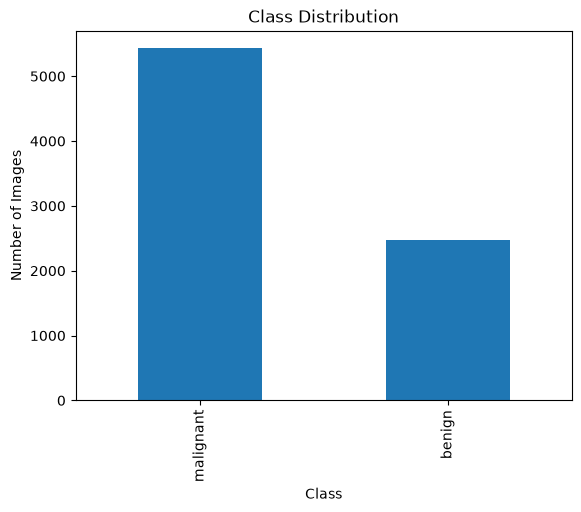

In [23]:
import matplotlib.pyplot as plt

df["class"].value_counts().plot(kind="bar")

plt.title("Class Distribution")

plt.xlabel("Class")

plt.ylabel("Number of Images")

plt.show()

In [24]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["class"],
    random_state=42
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["class"],
    random_state=42
)

print(len(train_df))
print(len(val_df))
print(len(test_df))

5061
1266
1582


In [42]:
import re
from sklearn.model_selection import train_test_split

def extract_patient_id(filepath):
    filename = os.path.basename(filepath)
    match = re.search(r'(SOB_[BM]_[A-Z]+_\d+-[A-Z]+)', filename)
    if match:
        return match.group(1)
    return os.path.basename(os.path.dirname(filepath))

df["patient_id"] = df["filename"].apply(extract_patient_id)

print("Number of unique patients:", df["patient_id"].nunique())
print(df[["filename", "class", "patient_id"]].head())

Number of unique patients: 4
                                            filename   class patient_id
0  C:\Users\bipla\.cache\kagglehub\datasets\ambar...  benign       100X
1  C:\Users\bipla\.cache\kagglehub\datasets\ambar...  benign       100X
2  C:\Users\bipla\.cache\kagglehub\datasets\ambar...  benign       100X
3  C:\Users\bipla\.cache\kagglehub\datasets\ambar...  benign       100X
4  C:\Users\bipla\.cache\kagglehub\datasets\ambar...  benign       100X


In [43]:
from pathlib import Path

def extract_patient_id(filepath):
    path = Path(filepath)
    return path.parent.parent.name

df["patient_id"] = df["filename"].apply(extract_patient_id)

print("Number of unique patients:", df["patient_id"].nunique())
print(df[["filename", "class", "patient_id"]].head())

Number of unique patients: 82
                                            filename   class  \
0  C:\Users\bipla\.cache\kagglehub\datasets\ambar...  benign   
1  C:\Users\bipla\.cache\kagglehub\datasets\ambar...  benign   
2  C:\Users\bipla\.cache\kagglehub\datasets\ambar...  benign   
3  C:\Users\bipla\.cache\kagglehub\datasets\ambar...  benign   
4  C:\Users\bipla\.cache\kagglehub\datasets\ambar...  benign   

           patient_id  
0  SOB_B_A_14-22549AB  
1  SOB_B_A_14-22549AB  
2  SOB_B_A_14-22549AB  
3  SOB_B_A_14-22549AB  
4  SOB_B_A_14-22549AB  


In [44]:
print("\nUnique patients:", df["patient_id"].nunique())

print("\nImages per class:")
print(df["class"].value_counts())

print("\nPatients by class:")
print(
    df.groupby("class")["patient_id"]
      .nunique()
)


Unique patients: 82

Images per class:
class
malignant    5429
benign       2480
Name: count, dtype: int64

Patients by class:
class
benign       24
malignant    58
Name: patient_id, dtype: int64


In [45]:
patient_class_check = (
    df.groupby("patient_id")["class"]
      .nunique()
)

print("Patients belonging to more than one class:",
      (patient_class_check > 1).sum())

Patients belonging to more than one class: 0


In [46]:
from sklearn.model_selection import train_test_split

patients = df[["patient_id", "class"]].drop_duplicates()

train_patients, test_patients = train_test_split(
    patients,
    test_size=0.20,
    stratify=patients["class"],
    random_state=42
)

train_patients, val_patients = train_test_split(
    train_patients,
    test_size=0.20,
    stratify=train_patients["class"],
    random_state=42
)

train_df = df[df["patient_id"].isin(train_patients["patient_id"])].copy()
val_df = df[df["patient_id"].isin(val_patients["patient_id"])].copy()
test_df = df[df["patient_id"].isin(test_patients["patient_id"])].copy()

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))

print("\nTraining patients:", len(train_patients))
print("Validation patients:", len(val_patients))
print("Testing patients:", len(test_patients))

print("\nTraining class distribution:")
print(train_df["class"].value_counts())

print("\nValidation class distribution:")
print(val_df["class"].value_counts())

print("\nTesting class distribution:")
print(test_df["class"].value_counts())

Training images: 5015
Validation images: 1139
Testing images: 1755

Training patients: 52
Validation patients: 13
Testing patients: 17

Training class distribution:
class
malignant    3583
benign       1432
Name: count, dtype: int64

Validation class distribution:
class
malignant    784
benign       355
Name: count, dtype: int64

Testing class distribution:
class
malignant    1062
benign        693
Name: count, dtype: int64


In [47]:
print(
    "Train/Test patient overlap:",
    len(set(train_df["patient_id"]) & set(test_df["patient_id"]))
)

print(
    "Train/Validation patient overlap:",
    len(set(train_df["patient_id"]) & set(val_df["patient_id"]))
)

print(
    "Validation/Test patient overlap:",
    len(set(val_df["patient_id"]) & set(test_df["patient_id"]))
)

Train/Test patient overlap: 0
Train/Validation patient overlap: 0
Validation/Test patient overlap: 0


In [48]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training augmentation + ResNet50 preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

# Validation and test: preprocessing only
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [49]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filename",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=42
)

validation_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filename",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filename",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 5015 validated image filenames belonging to 2 classes.
Found 1139 validated image filenames belonging to 2 classes.
Found 1755 validated image filenames belonging to 2 classes.


In [50]:
print("Class mapping:", train_generator.class_indices)

print("Training samples:", train_generator.samples)
print("Validation samples:", validation_generator.samples)
print("Test samples:", test_generator.samples)

Class mapping: {'benign': 0, 'malignant': 1}
Training samples: 5015
Validation samples: 1139
Test samples: 1755


In [51]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_generator.classes)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_generator.classes
)

class_weights = dict(zip(classes, class_weights_array))

print("Class weights:")
print(class_weights)

print("\nTraining class distribution:")
print(train_df["class"].value_counts())

Class weights:
{np.int64(0): np.float64(1.7510474860335195), np.int64(1): np.float64(0.6998325425620988)}

Training class distribution:
class
malignant    3583
benign       1432
Name: count, dtype: int64


In [52]:
import tensorflow as tf

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# Load pretrained ResNet50
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained convolutional layers
base_model.trainable = False

# Classification head
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

# Complete model
model = Model(
    inputs=base_model.input,
    outputs=output
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [53]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [54]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

print("ImageDataGenerator created successfully.")

ImageDataGenerator created successfully.


In [26]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filename",
    y_col="class",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    shuffle=True
)

print("Train Generator Created")

Found 5061 validated image filenames belonging to 2 classes.
Train Generator Created


In [27]:
validation_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filename",
    y_col="class",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    shuffle=True
)

print("Validation Generator Created")

Found 1266 validated image filenames belonging to 2 classes.
Validation Generator Created


In [28]:
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filename",
    y_col="class",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

print("Test Generator Created")

Found 1582 validated image filenames belonging to 2 classes.
Test Generator Created


In [29]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filename",
    y_col="class",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=True
)

Found 5061 validated image filenames belonging to 2 classes.


In [30]:
validation_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filename",
    y_col="class",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=True
)

Found 1266 validated image filenames belonging to 2 classes.


In [31]:
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filename",
    y_col="class",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 1582 validated image filenames belonging to 2 classes.


In [32]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

# Load pretrained ResNet50
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pretrained layers
base_model.trainable = False

# Add custom classification layers
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

# Final model
model = Model(inputs=base_model.input, outputs=output)

print("ResNet50 model created successfully!")

ResNet50 model created successfully!


In [33]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [34]:
model.summary(line_length=150)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━
┃ Layer (type)                               ┃ Output Shape                         ┃                 Param # ┃ Con
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━
│ input_layer_1 (InputLayer)                 │ (None, 224, 224, 3)                  │                       0 │ -  
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ conv1_pad (ZeroPadding2D)                  │ (None, 230, 230, 3)                  │                       0 │ inp
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ conv1_conv (Conv2D)                        │ (None, 112, 112, 64)                 │                   9,472 │ con
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ conv1_bn (BatchNormalization)              │ (None, 112, 112, 64)                 │                     256 │ con
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ conv1_relu (Activation)                    │ (None, 112, 112, 64)                 │                       0 │ con
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ pool1_pad (ZeroPadding2D)                  │ (None, 114, 114, 64)                 │                       0 │ con
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ pool1_pool (MaxPooling2D)                  │ (None, 56, 56, 64)                   │                       0 │ poo
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ conv2_block1_1_conv (Conv2D)               │ (None, 56, 56, 64)                   │                   4,160 │ poo
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ conv2_block1_1_bn (BatchNormalization)     │ (None, 56, 56, 64)                   │                     256 │ con
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ conv2_block1_1_relu (Activation)           │ (None, 56, 56, 64)                   │                       0 │ con
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ conv2_block1_2_conv (Conv2D)               │ (None, 56, 56, 64)                   │                  36,928 │ con
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ conv2_block1_2_bn (BatchNormalization)     │ (None, 56, 56, 64)                   │                     256 │ con
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ conv2_block1_2_relu (Activation)           │ (None, 56, 56, 64)                   │                       0 │ con
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ conv2_block1_0_conv (Conv2D)               │ (None, 56, 56, 256)                  │                  16,640 │ poo
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ conv2_block1_3_conv (Conv2D)               │ (None, 56, 56, 256)                  │                  16,640 │ con
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ conv2_block1_0_bn (BatchNormalization)     │ (None, 56, 56, 256)                  │                   1,024 │ con
├────────────────────────────────────────────┼──────────

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [35]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=2,
    verbose=1
)

Epoch 1/2
159/159 ━━━━━━━━━━━━━━━━━━━━ 734s 4s/step - accuracy: 0.6860 - loss: 0.6284 - val_accuracy: 0.5987 - val_loss: 0.6545
Epoch 2/2
159/159 ━━━━━━━━━━━━━━━━━━━━ 671s 4s/step - accuracy: 0.6714 - loss: 0.6333 - val_accuracy: 0.6888 - val_loss: 0.6135


In [36]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

50/50 ━━━━━━━━━━━━━━━━━━━━ 217s 4s/step - accuracy: 0.6865 - loss: 0.6163
Test Accuracy: 0.6864728331565857
Test Loss: 0.6163384318351746


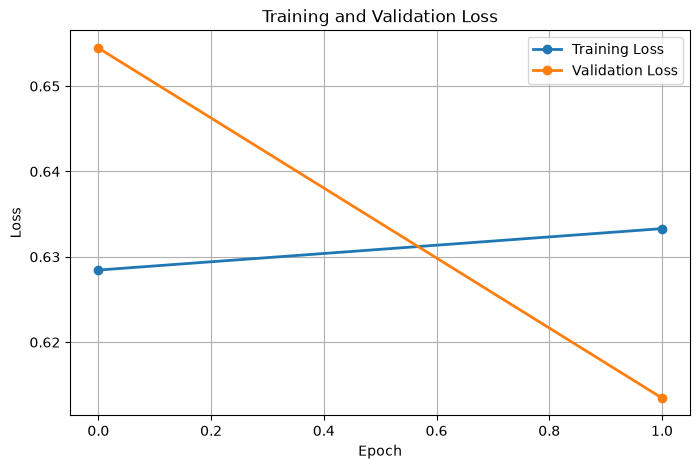

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],
         marker='o',
         linewidth=2,
         label='Training Loss')

plt.plot(history.history['val_loss'],
         marker='o',
         linewidth=2,
         label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')

plt.legend()
plt.grid(True)

plt.savefig("Loss_Curve.png", dpi=300, bbox_inches='tight')

plt.show()

50/50 ━━━━━━━━━━━━━━━━━━━━ 199s 4s/step
[[   0  496]
 [   0 1086]]


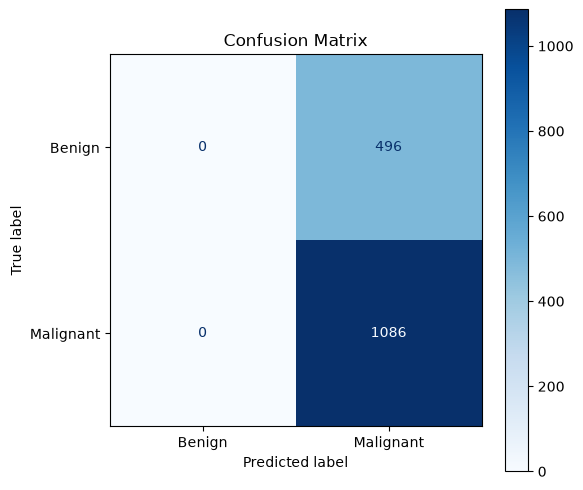

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict on test data
predictions = model.predict(test_generator)

# Convert probabilities to binary labels
y_pred = (predictions > 0.5).astype(int).flatten()

# True labels
y_true = test_generator.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print(cm)

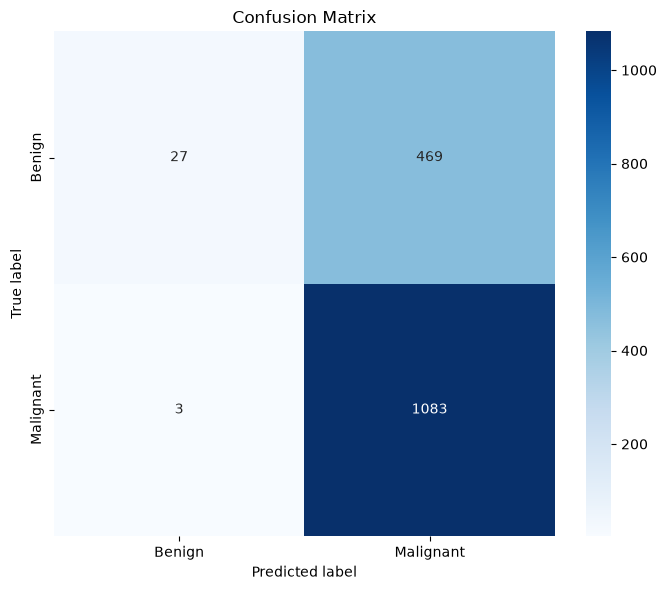

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cm = np.array([
    [27, 469],
    [3, 1083]
])

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

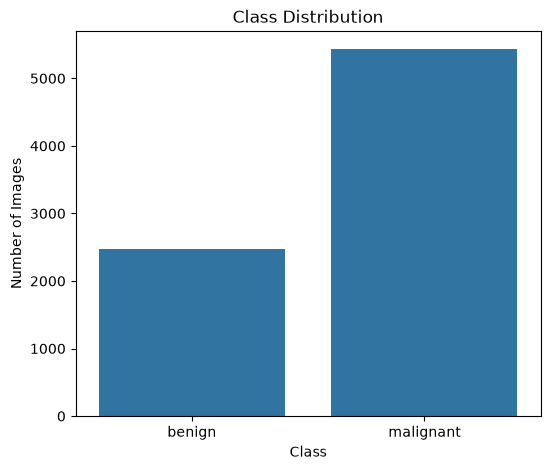

class
malignant    5429
benign       2480
Name: count, dtype: int64


In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.countplot(
    x=df["class"],
    order=["benign","malignant"]
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.savefig("Class_Distribution.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

print(df["class"].value_counts())

In [58]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_true,
    y_pred,
    target_names=["Benign","Malignant"],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print(report_df)

report_df.to_csv("Classification_Performance.csv")

              precision    recall  f1-score      support
Benign         0.000000  0.000000  0.000000   496.000000
Malignant      0.686473  1.000000  0.814093  1086.000000
accuracy       0.686473  0.686473  0.686473     0.686473
macro avg      0.343236  0.500000  0.407046  1582.000000
weighted avg   0.471245  0.686473  0.558853  1582.000000


c:\Users\bipla\breastcancer_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bipla\breastcancer_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bipla\breastcancer_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [59]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)

x = Dense(128, activation='relu')(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input,
              outputs=output)

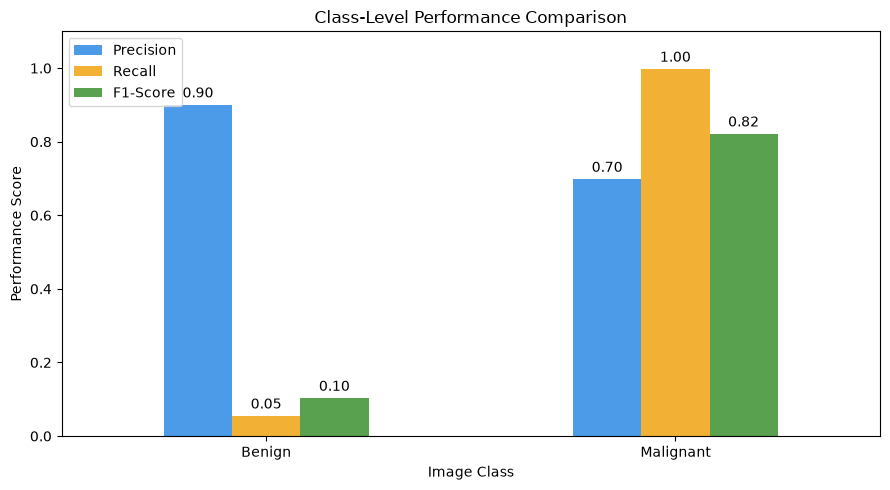

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

performance = pd.DataFrame({
    'Class': ['Benign', 'Malignant'],
    'Precision': [0.9000, 0.6978],
    'Recall': [0.0544, 0.9972],
    'F1-Score': [0.1027, 0.8211]
})

performance_plot = performance.set_index('Class')

ax = performance_plot.plot(
    kind='bar',
    figsize=(9, 5),
    color=['#4C9BE8', '#F2B134', '#59A14F']
)

plt.title('Class-Level Performance Comparison')
plt.xlabel('Image Class')
plt.ylabel('Performance Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc='upper left')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

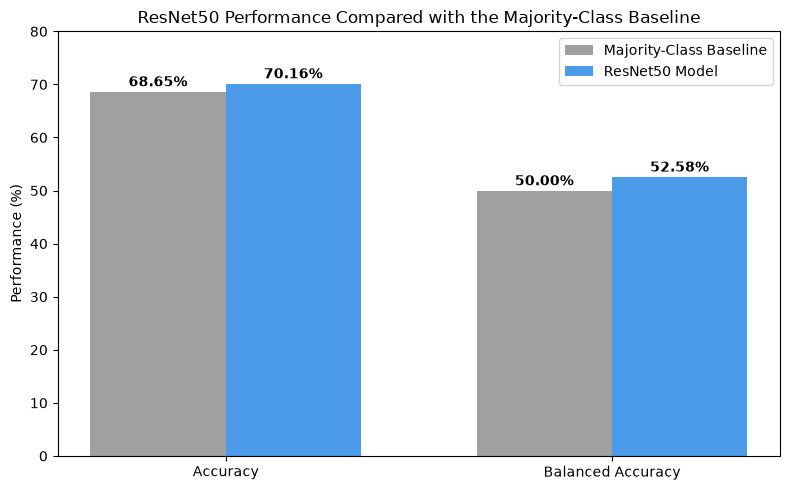

In [64]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ['Accuracy', 'Balanced Accuracy']
baseline = [68.65, 50.00]
resnet50 = [70.16, 52.58]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))

bars1 = plt.bar(
    x - width/2, baseline, width,
    label='Majority-Class Baseline',
    color='#A0A0A0'
)

bars2 = plt.bar(
    x + width/2, resnet50, width,
    label='ResNet50 Model',
    color='#4C9BE8'
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'{bar.get_height():.2f}%',
            ha='center',
            fontweight='bold'
        )

plt.xticks(x, metrics)
plt.ylabel('Performance (%)')
plt.title('ResNet50 Performance Compared with the Majority-Class Baseline')
plt.ylim(0, 80)
plt.legend()
plt.tight_layout()
plt.show()

Sample Histopathological Images

In [68]:
%pip install graphviz

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:
from graphviz import Digraph

print("Graphviz Python package is working")

Graphviz Python package is working


In [74]:
print("Class mapping:", test_generator.class_indices)

Class mapping: {'benign': 0, 'malignant': 1}


In [76]:
# Reset test generator to ensure predictions match the correct test order
test_generator.reset()

# Generate predicted probabilities
y_probability = model.predict(
    test_generator,
    verbose=1
).ravel()

# True labels
y_true = test_generator.classes

print("Number of true labels:", len(y_true))
print("Number of predictions:", len(y_probability))
print("First 10 probabilities:", y_probability[:10])

55/55 ━━━━━━━━━━━━━━━━━━━━ 295s 5s/step
Number of true labels: 1755
Number of predictions: 1755
First 10 probabilities: [0.35292688 0.26456168 0.59858    0.63017535 0.70775414 0.40292928
 0.48818326 0.65893435 0.4109795  0.51145864]


In [77]:
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

roc_auc = roc_auc_score(y_true, y_probability)
average_precision = average_precision_score(y_true, y_probability)

false_positive_rate, true_positive_rate, roc_thresholds = roc_curve(
    y_true,
    y_probability
)

precision, recall, pr_thresholds = precision_recall_curve(
    y_true,
    y_probability
)

print(f"ROC–AUC Score: {roc_auc:.4f}")
print(f"Average Precision Score: {average_precision:.4f}")

ROC–AUC Score: 0.6106
Average Precision Score: 0.7159
